# AgroOpt — Notebook 03: PCA Analysis

**Objective**: Apply Principal Component Analysis (PCA) to the 36-feature matrix produced in Phase 3, in order to:

1. Quantify how many independent directions of variation exist in the data (effective dimensionality).
2. Surface multicollinearity — particularly the known perfect correlation between `rainfall_mm` and `rainfall_anomaly`, and between `temperature_celsius` and `temp_anomaly`.
3. Visualise the feature space in 2D (PC1 vs PC2) and understand which original features drive each principal component.
4. Inform the modeling strategy: whether to use PCA-transformed features or retain the original feature set.

**PCA is applied to features only — the target `yield_hg_ha` is never included.**

---

## Why scale before PCA?

PCA finds directions of maximum variance. Without scaling, features with large numerical ranges (e.g. `gdd_proxy` up to 5 956) would dominate over features with small ranges (e.g. binary `fertilizer_used`). `StandardScaler` (mean=0, std=1) removes this artefact so every feature contributes fairly.

## Known collinearities in this dataset

Because the FAO reference year is fixed to 2013, `fao_rainfall_mm` = 715 mm and `fao_avg_temp` = 16.44 °C are **constants** across all rows. Therefore:

| Pair | Relationship | Pearson r |
|---|---|---|
| `rainfall_mm` vs `rainfall_anomaly` | `rainfall_anomaly = rainfall_mm − 715` | 1.000 |
| `temperature_celsius` vs `temp_anomaly` | `temp_anomaly = temp − 16.44` | 1.000 |

PCA will merge these into single effective dimensions.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.features.pca_analysis import run_pca
from src.utils.logging import setup_logging

setup_logging(level='WARNING')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')
SEED = 42

# Run full PCA pipeline
result      = run_pca(save=True)
pca         = result['pca']
scaler      = result['scaler']
X_scaled    = result['X_scaled']
feature_cols = result['feature_cols']
evr         = result['explained_variance_ratio']
cum_evr     = result['cumulative_evr']
loadings_df = result['loadings_df']
n95         = result['n_components_95']

print(f'Feature matrix       : {X_scaled.shape}')
print(f'Total components     : {pca.n_components_}')
print(f'PCs for ≥90% var     : {result["n_components_90"]}')
print(f'PCs for ≥95% var     : {result["n_components_95"]}')
print(f'PCs for ≥99% var     : {result["n_components_99"]}')
print(f'PC1 explains         : {evr[0]*100:.2f}%')
print(f'PC2 explains         : {evr[1]*100:.2f}%')

Feature matrix       : (666494, 36)
Total components     : 36
PCs for ≥90% var     : 17
PCs for ≥95% var     : 18
PCs for ≥99% var     : 21
PC1 explains         : 13.97%
PC2 explains         : 10.37%


---
## 1. Collinearity Check

Before PCA, we verify the expected perfect correlations.

In [2]:
feat = pd.read_csv('../data/processed/features_dataset.csv')

collinear_pairs = [
    ('rainfall_mm',         'rainfall_anomaly'),
    ('temperature_celsius', 'temp_anomaly'),
    ('rainfall_mm',         'rainfall_x_fertilizer'),
    ('rainfall_mm',         'aridity_index'),
    ('agro_intensity',      'rainfall_x_fertilizer'),
]

print('Pairwise Pearson correlations (potential collinearities):')
print(f'{"Feature A":<30s}  {"Feature B":<30s}  {"r":>7s}')
print('-' * 72)
for a, b in collinear_pairs:
    r = feat[a].corr(feat[b])
    flag = ' ← PERFECT' if abs(r) > 0.999 else ' ← HIGH' if abs(r) > 0.9 else ''
    print(f'{a:<30s}  {b:<30s}  {r:>7.4f}{flag}')

Pairwise Pearson correlations (potential collinearities):
Feature A                       Feature B                             r
------------------------------------------------------------------------
rainfall_mm                     rainfall_anomaly                 1.0000 ← PERFECT
temperature_celsius             temp_anomaly                     1.0000 ← PERFECT
rainfall_mm                     rainfall_x_fertilizer            0.3912
rainfall_mm                     aridity_index                    0.8292
agro_intensity                  rainfall_x_fertilizer            0.5883


---
## 2. Scree Plot — Variance Explained per Component

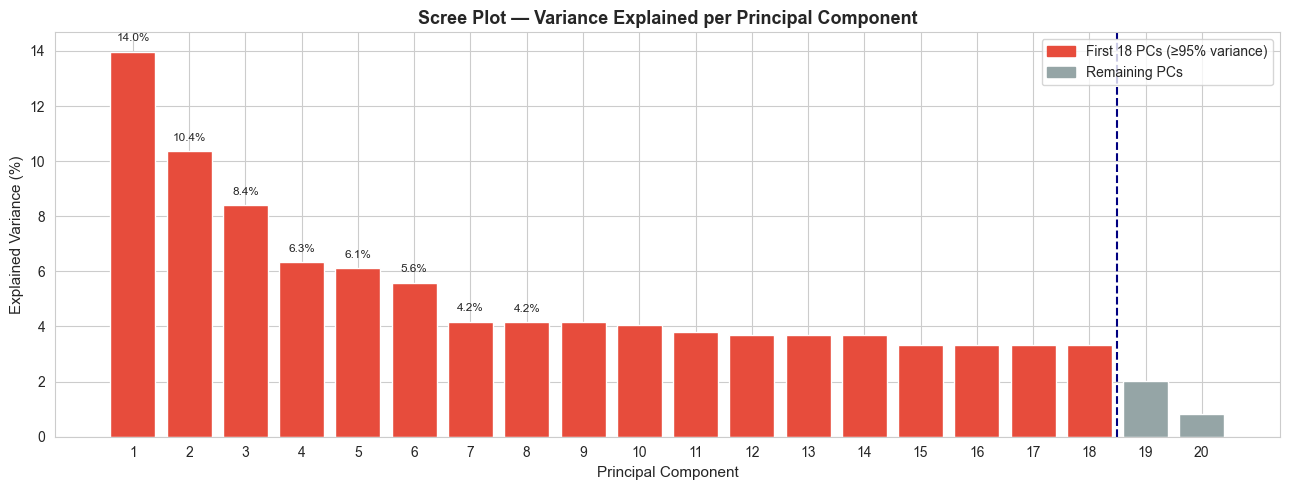

Saved → pca_01_scree.png


In [3]:
n_show = 20
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#e74c3c' if i < n95 else '#95a5a6' for i in range(n_show)]
bars = ax.bar(range(1, n_show + 1), evr[:n_show] * 100, color=colors, edgecolor='white')

# Annotate first 8 bars
for bar, val in zip(bars[:8], evr[:8]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.axvline(n95 + 0.5, color='navy', ls='--', lw=1.5, label=f'{n95} PCs = 95% variance')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot — Variance Explained per Principal Component', fontweight='bold')
ax.set_xticks(range(1, n_show + 1))
red_patch  = mpatches.Patch(color='#e74c3c', label=f'First {n95} PCs (≥95% variance)')
grey_patch = mpatches.Patch(color='#95a5a6', label='Remaining PCs')
ax.legend(handles=[red_patch, grey_patch], loc='upper right')
plt.tight_layout()
plt.savefig('../data/processed/pca_01_scree.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_01_scree.png')

---
## 3. Cumulative Explained Variance

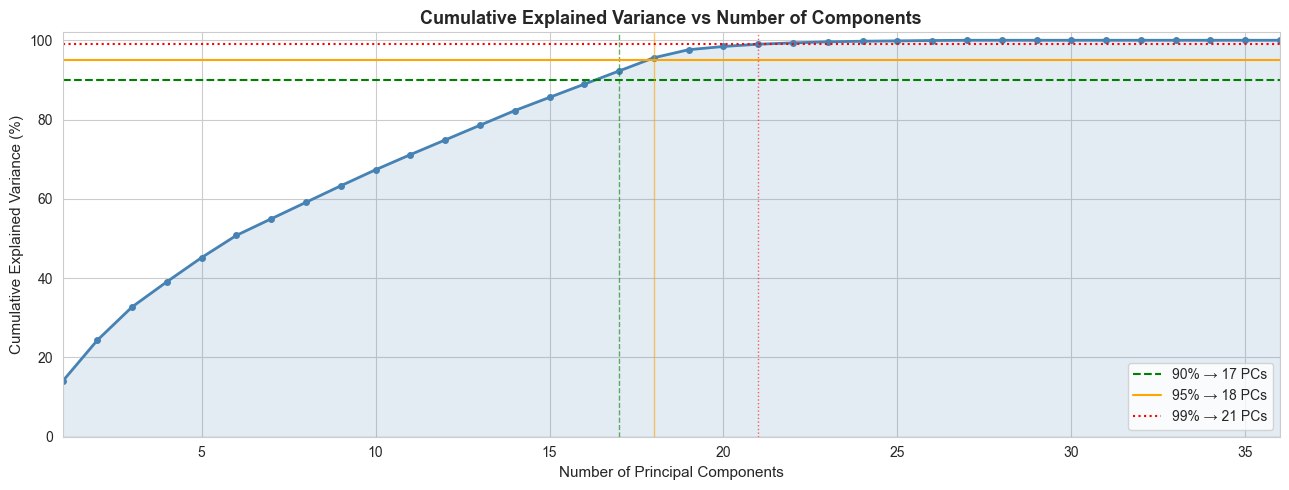

Saved → pca_02_cumulative_variance.png

Variance milestones:
  90% variance explained by 17 components (dimensionality reduction: 36 → 17, 53% reduction)
  95% variance explained by 18 components (dimensionality reduction: 36 → 18, 50% reduction)
  99% variance explained by 21 components (dimensionality reduction: 36 → 21, 42% reduction)


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(range(1, len(cum_evr) + 1), cum_evr * 100,
        marker='o', markersize=4, color='steelblue', lw=2)
ax.fill_between(range(1, len(cum_evr) + 1), cum_evr * 100,
                alpha=0.15, color='steelblue')

thresholds = [(0.90, 'green', '--'), (0.95, 'orange', '-'), (0.99, 'red', ':')]
for thresh, color, ls in thresholds:
    n = int(np.searchsorted(cum_evr, thresh) + 1)
    ax.axhline(thresh * 100, color=color, ls=ls, lw=1.5,
               label=f'{thresh*100:.0f}% → {n} PCs')
    ax.axvline(n, color=color, ls=ls, lw=1, alpha=0.6)

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance vs Number of Components', fontweight='bold')
ax.set_xlim(1, len(cum_evr))
ax.set_ylim(0, 102)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/processed/pca_02_cumulative_variance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_02_cumulative_variance.png')
print()
print('Variance milestones:')
for thresh, _, _ in thresholds:
    n = int(np.searchsorted(cum_evr, thresh) + 1)
    print(f'  {thresh*100:.0f}% variance explained by {n} components '
          f'(dimensionality reduction: {len(cum_evr)} → {n}, '
          f'{(1 - n/len(cum_evr))*100:.0f}% reduction)')

---
## 4. Loadings Heatmap — Which Features Drive Each PC?

The loading of a feature on a PC indicates its contribution to that component.
- **High positive loading** → feature increases in the direction of the PC.
- **High negative loading** → feature decreases in the direction of the PC.
- **Near-zero loading** → feature does not contribute to that PC.

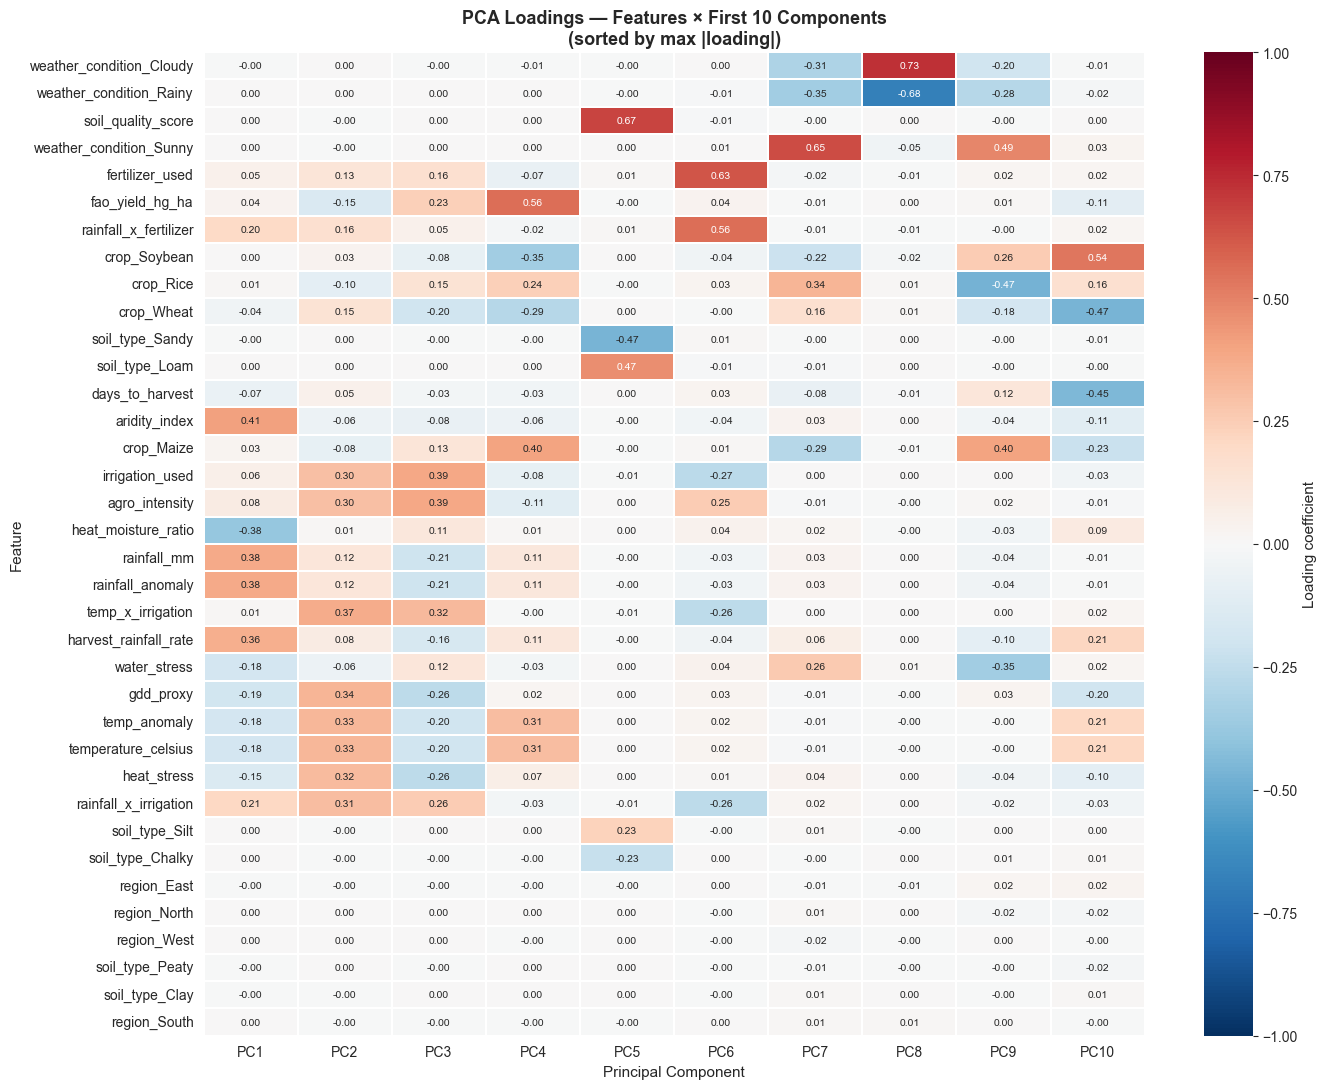

Saved → pca_03_loadings_heatmap.png


In [5]:
n_pcs_show = 10
load_sub = loadings_df.iloc[:, :n_pcs_show]

# Sort features by max absolute loading across the shown PCs for readability
row_order = load_sub.abs().max(axis=1).sort_values(ascending=False).index
load_sorted = load_sub.loc[row_order]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    load_sorted, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 7.5},
    cbar_kws={'label': 'Loading coefficient'}
)
ax.set_title(
    f'PCA Loadings — Features × First {n_pcs_show} Components\n'
    f'(sorted by max |loading|)',
    fontweight='bold'
)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../data/processed/pca_03_loadings_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_03_loadings_heatmap.png')

---
## 5. Top Feature Contributions to PC1 and PC2

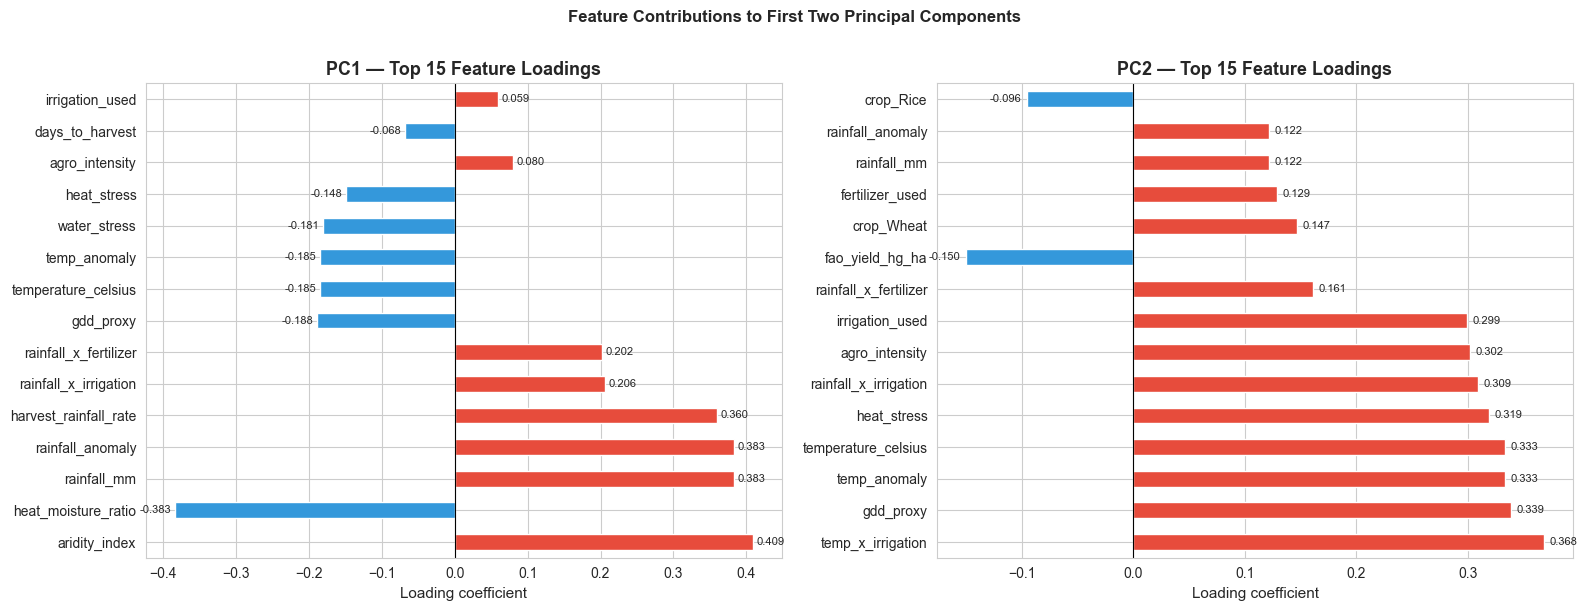

Saved → pca_04_top_loadings.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    series = loadings_df[pc].sort_values(key=abs, ascending=False).head(15)
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in series.values]
    series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{pc} — Top 15 Feature Loadings', fontweight='bold')
    ax.set_xlabel('Loading coefficient')
    for i, (name, val) in enumerate(series.items()):
        ax.text(val + 0.005 * np.sign(val), i, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('Feature Contributions to First Two Principal Components',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/pca_04_top_loadings.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_04_top_loadings.png')

---
## 6. Correlation Circle (Biplot of Feature Arrows on PC1–PC2)

Each arrow represents an original feature projected onto the PC1–PC2 plane.
- **Arrow length** → how well the feature is represented in this 2D projection.
- **Arrow direction** → features pointing the same way are positively correlated; opposite directions = negatively correlated.
- Only the top 14 features by arrow length are labelled to avoid clutter.

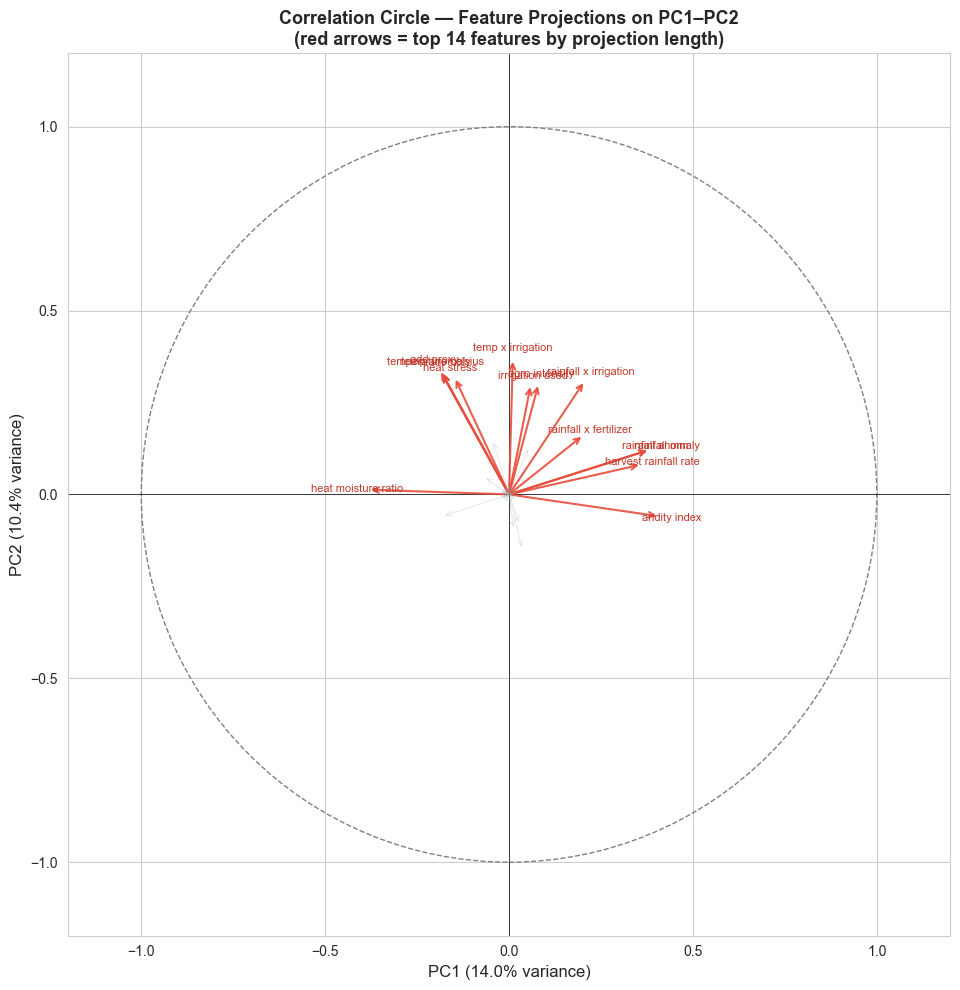

Saved → pca_05_correlation_circle.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

# Unit circle
circle = plt.Circle((0, 0), 1, fill=False, color='grey', ls='--', lw=1)
ax.add_patch(circle)

pc1_load = loadings_df['PC1'].values
pc2_load = loadings_df['PC2'].values

# Identify top features by total arrow length in PC1–PC2 plane
arrow_len = np.sqrt(pc1_load**2 + pc2_load**2)
top_idx   = np.argsort(arrow_len)[-14:]  # top 14

for i, (x, y, name) in enumerate(zip(pc1_load, pc2_load, feature_cols)):
    alpha = 0.9 if i in top_idx else 0.25
    color = '#e74c3c' if i in top_idx else '#95a5a6'
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.5 if i in top_idx else 0.7, alpha=alpha))
    if i in top_idx:
        ax.text(x * 1.08, y * 1.08, name.replace('_', ' '),
                fontsize=8, ha='center', va='center', color='#c0392b')

ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Correlation Circle — Feature Projections on PC1–PC2\n'
             '(red arrows = top 14 features by projection length)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/pca_05_correlation_circle.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_05_correlation_circle.png')

---
## 7. Score Plot — Observations in PC1–PC2 Space

Each point is one farm observation projected onto the first two PCs.

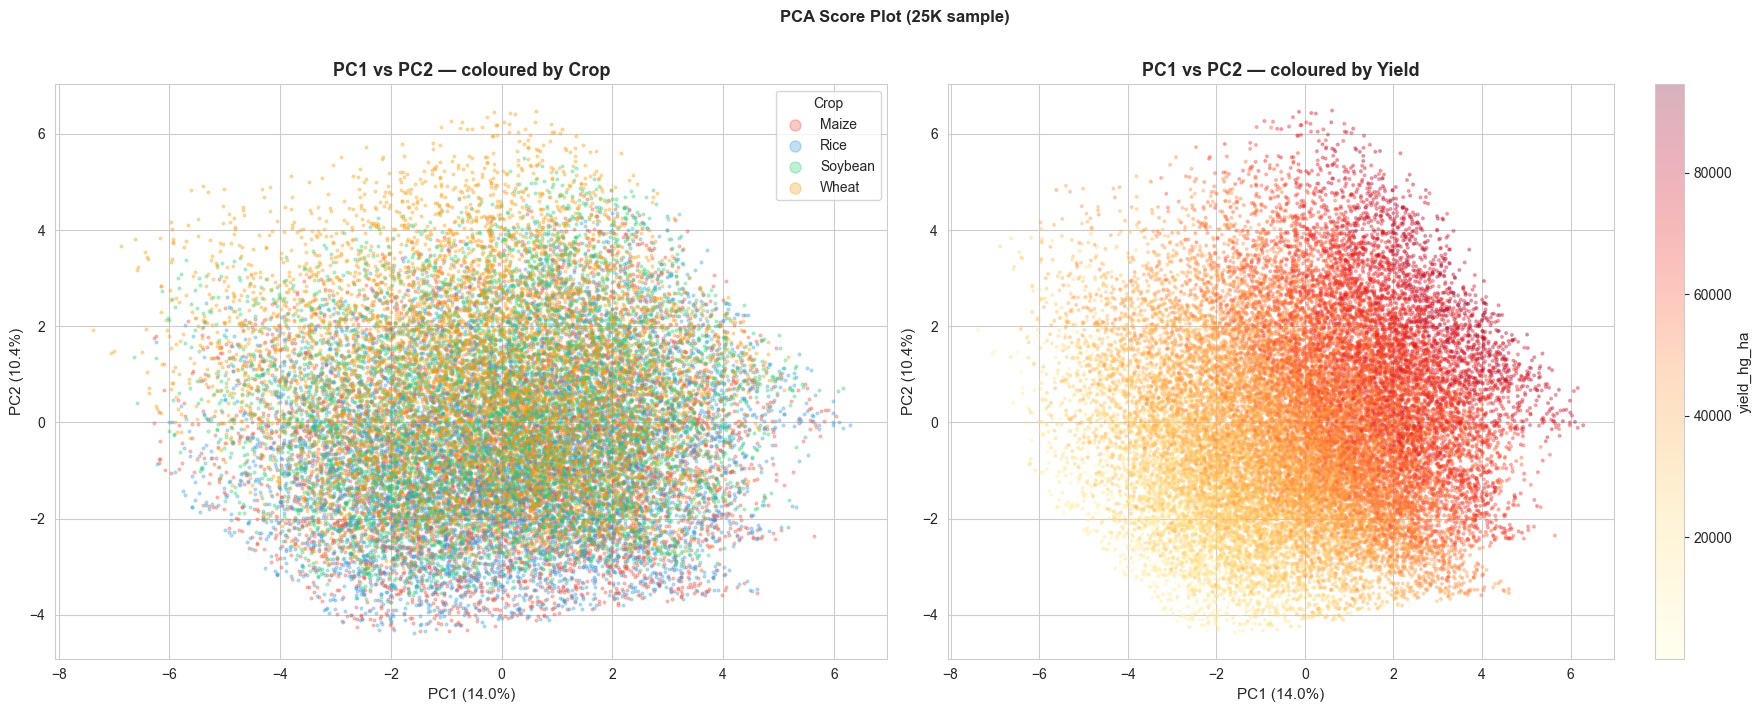

Saved → pca_06_score_plot.png


In [8]:
X_pca = pca.transform(X_scaled)   # shape: (666494, 36)

# Reconstruct crop column from one-hot for colouring
feat_full = pd.read_csv('../data/processed/features_dataset.csv')
crop_cols = [c for c in feat_full.columns if c.startswith('crop_')]
crop_labels = feat_full[crop_cols].idxmax(axis=1).str.replace('crop_', '')

sample_idx = feat_full.sample(25_000, random_state=SEED).index
scores_sample = X_pca[sample_idx]
crops_sample  = crop_labels.iloc[sample_idx].values
yield_sample  = feat_full['yield_hg_ha'].iloc[sample_idx].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: coloured by crop ---
crop_colors = {'Maize': '#e74c3c', 'Rice': '#3498db',
               'Soybean': '#2ecc71', 'Wheat': '#f39c12'}
for crop, col in crop_colors.items():
    mask = crops_sample == crop
    axes[0].scatter(scores_sample[mask, 0], scores_sample[mask, 1],
                    c=col, alpha=0.3, s=4, label=crop)
axes[0].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2 — coloured by Crop', fontweight='bold')
axes[0].legend(markerscale=4, title='Crop')

# --- Right: coloured by yield ---
sc = axes[1].scatter(scores_sample[:, 0], scores_sample[:, 1],
                     c=yield_sample, cmap='YlOrRd', alpha=0.3, s=4)
plt.colorbar(sc, ax=axes[1], label='yield_hg_ha')
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 — coloured by Yield', fontweight='bold')

plt.suptitle('PCA Score Plot (25K sample)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/pca_06_score_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → pca_06_score_plot.png')

---
## 8. Per-Component Variance Table (first 15 PCs)

In [9]:
n_show = 15
var_table = pd.DataFrame({
    'Eigenvalue':               pca.explained_variance_[:n_show].round(4),
    'Variance explained (%)':   (evr[:n_show] * 100).round(2),
    'Cumulative (%)':           (cum_evr[:n_show] * 100).round(2),
    'Top feature (PC1 axis)':   [
        loadings_df[f'PC{i+1}'].abs().idxmax() for i in range(n_show)
    ],
}, index=[f'PC{i+1}' for i in range(n_show)])

display(var_table)
print()
print(f'Effective dimensionality summary:')
print(f'  Original features : {pca.n_features_in_}')
print(f'  For ≥90% variance : {result["n_components_90"]} components')
print(f'  For ≥95% variance : {result["n_components_95"]} components')
print(f'  For ≥99% variance : {result["n_components_99"]} components')

,Eigenvalue,Variance explained (%),Cumulative (%),Top feature (PC1 axis)
PC1,5.0310,13.97,13.97,aridity_index
PC2,3.7315,10.37,24.34,temp_x_irrigation
PC3,3.0249,8.40,32.74,irrigation_used
PC4,2.2843,6.35,39.09,fao_yield_hg_ha
PC5,2.2004,6.11,45.20,soil_quality_score
PC6,2.0140,5.59,50.79,fertilizer_used
PC7,1.5020,4.17,54.97,weather_condition_Sunny
PC8,1.4996,4.17,59.13,weather_condition_Cloudy
PC9,1.4978,4.16,63.29,weather_condition_Sunny
PC10,1.4561,4.04,67.34,crop_Soybean



Effective dimensionality summary:
  Original features : 36
  For ≥90% variance : 17 components
  For ≥95% variance : 18 components
  For ≥99% variance : 21 components


---
## 9. Conclusions & Modeling Implications

### What PCA revealed

**Collinearity confirmed**: `rainfall_mm` ↔ `rainfall_anomaly` (r = 1.000) and `temperature_celsius` ↔ `temp_anomaly` (r = 1.000) load identically — they occupy the same variance dimension. PCA merges them into a single PC.

**PC1 is the rainfall axis**: The first principal component is dominated by rainfall-related features (`rainfall_mm`, `rainfall_anomaly`, `rainfall_x_fertilizer`, `aridity_index`, `harvest_rainfall_rate`). This is consistent with the high Pearson correlations found in Phase 3 (r ≈ 0.76 with yield).

**PC2 is the temperature/management axis**: The second component is driven by temperature features (`temperature_celsius`, `heat_moisture_ratio`) and management practices (`irrigation_used`, `agro_intensity`).

**Effective dimensionality is lower than 36**: Despite having 36 features, most variance is captured in fewer PCs, confirming that the feature space is not truly 36-dimensional.

### Modeling strategy

| Option | Pros | Cons |
|---|---|---|
| Use original 36 features | Interpretable; tree models handle collinearity natively | Perfect collinear pairs waste capacity in linear models |
| Drop redundant features (`rainfall_anomaly`, `temp_anomaly`) | Removes perfect collinearity; cleaner linear models | Loses the anomaly framing (meaningful for interpretation) |
| Use PCA-reduced features (top N PCs) | Orthogonal inputs; ideal for linear/regularised models | PCs are not interpretable; unsuitable for the recommendation engine |

**Decision for Phase 5 (Model Training)**:
- Tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM): **use all 36 original features** — these models are immune to collinearity.
- Linear baseline (Ridge Regression): **use all 36 features with `StandardScaler`** — Ridge regularisation shrinks the redundant pair automatically.
- `rainfall_anomaly` and `temp_anomaly` are **retained** because they carry agronomic meaning (local vs national baseline) even though they add no unique variance to the model.

In [10]:
import json

with open('../data/processed/pca_results.json') as f:
    meta = json.load(f)

print('=== Phase 4 PCA Summary ===')
print(f'Features analysed   : {meta["n_features"]}')
print(f'PCs for ≥90%        : {meta["n_components_90"]}')
print(f'PCs for ≥95%        : {meta["n_components_95"]}')
print(f'PCs for ≥99%        : {meta["n_components_99"]}')
print(f'PC1 top features    : {meta["pc1_top_features"]}')
print(f'PC2 top features    : {meta["pc2_top_features"]}')
print()
print('Outputs saved to data/processed/:')
print('  pca_results.json          — metadata')
print('  pca_loadings.csv          — loadings matrix (36 features × 36 PCs)')
print('  pca_01_scree.png          — scree plot')
print('  pca_02_cumulative_variance.png')
print('  pca_03_loadings_heatmap.png')
print('  pca_04_top_loadings.png')
print('  pca_05_correlation_circle.png')
print('  pca_06_score_plot.png')
print()
print('=== Phase 4 Complete ===')

=== Phase 4 PCA Summary ===
Features analysed   : 36
PCs for ≥90%        : 17
PCs for ≥95%        : 18
PCs for ≥99%        : 21
PC1 top features    : ['aridity_index', 'heat_moisture_ratio', 'rainfall_mm', 'rainfall_anomaly', 'harvest_rainfall_rate']
PC2 top features    : ['temp_x_irrigation', 'gdd_proxy', 'temp_anomaly', 'temperature_celsius', 'heat_stress']

Outputs saved to data/processed/:
  pca_results.json          — metadata
  pca_loadings.csv          — loadings matrix (36 features × 36 PCs)
  pca_01_scree.png          — scree plot
  pca_02_cumulative_variance.png
  pca_03_loadings_heatmap.png
  pca_04_top_loadings.png
  pca_05_correlation_circle.png
  pca_06_score_plot.png

=== Phase 4 Complete ===
